# Exploratory Data Analysis (EDA): Google Trends, HCUP, & U.S. Census Bureau
**Author:** J. Casey Brookshier  
**Date:** July 22, 2026

## Objective

Prepare and explore a state-year dataset to evaluate whether suicide- and crisis-related 
Google Trends search activity is associated with future state-level inpatient psychiatric admissions.


## Workflow

**Summarize → Visualize → Assess Relationships → Identify Preprocessing Needs**


In [1]:
import os

print(os.getcwd())
print(os.path.exists(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/DS Portfolio github friendly/Team-Rho-Capstone-Project.cb/data/processed"
))

/Users/caseybrookshier
True


In [2]:
# TEAM RHO EDA

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


# load data


DATA = Path(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/"
    "DS Portfolio github friendly/"
    "Team-Rho-Capstone-Project.cb/data/raw/"
    "team_rho_state_year_prediction_dataset.csv"
)

df = pd.read_csv(DATA)

print(df.shape)
display(df.head())

(452, 13)


,State,Year,state_population,mental_health_admissions,admission_rate_per_100k,suicidal thoughts_lag1,suicide hotline_lag1,self harm_lag1,mental health crisis_lag1,suicide prevention_lag1,crisis hotline_lag1,psychiatric hospital_lag1,depression help_lag1
0,Alaska,2015,738430.0,2200.0,297.929391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,2016,742575.0,2150.0,289.533044,0.000000,0.000000,16.000000,0.0,9.250000,0.0,0.000000,0.000000
2,Alaska,2017,740983.0,2250.0,303.650691,0.000000,0.000000,6.333333,0.0,12.750000,0.0,0.000000,13.250000
3,Alaska,2018,736624.0,2350.0,319.023002,7.666667,24.333333,7.500000,0.0,3.666667,0.0,0.000000,6.416667
4,Alaska,2019,733603.0,2450.0,333.968100,0.000000,22.000000,0.000000,0.0,18.333333,0.0,8.333333,5.583333


In [3]:
# sataset information

print(df.info())

print("\nMissing Values")
display(df.isna().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   State                      452 non-null    object 
 1   Year                       452 non-null    int64  
 2   state_population           452 non-null    float64
 3   mental_health_admissions   452 non-null    float64
 4   admission_rate_per_100k    452 non-null    float64
 5   suicidal thoughts_lag1     450 non-null    float64
 6   suicide hotline_lag1       450 non-null    float64
 7   self harm_lag1             450 non-null    float64
 8   mental health crisis_lag1  450 non-null    float64
 9   suicide prevention_lag1    450 non-null    float64
 10  crisis hotline_lag1        450 non-null    float64
 11  psychiatric hospital_lag1  450 non-null    float64
 12  depression help_lag1       450 non-null    float64
dtypes: float64(11), int64(1), object(1)
memory usage: 

State                        0
Year                         0
state_population             0
mental_health_admissions     0
admission_rate_per_100k      0
suicidal thoughts_lag1       2
suicide hotline_lag1         2
self harm_lag1               2
mental health crisis_lag1    2
suicide prevention_lag1      2
crisis hotline_lag1          2
psychiatric hospital_lag1    2
depression help_lag1         2
dtype: int64


Duplicate Rows: 0


In [4]:
# continuous descriptive stats

continuous = df.select_dtypes(include=np.number)

desc = continuous.describe().T

desc["median"] = continuous.median()

desc["skew"] = continuous.skew()

desc["kurtosis"] = continuous.kurtosis()

display(desc)

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
Year,452.0,2.018485e+03,2.849862e+00,2014.000000,2.016000e+03,2.018000e+03,2.021000e+03,2.023000e+03,2.018000e+03,0.006103,-1.207609
state_population,452.0,6.856513e+06,7.384390e+06,579054.000000,1.957911e+06,4.995066e+06,8.565122e+06,3.943761e+07,4.995066e+06,2.439334,6.855473
mental_health_admissions,452.0,2.696106e+04,2.935438e+04,1150.000000,8.337500e+03,1.605000e+04,3.356250e+04,1.451000e+05,1.605000e+04,2.040070,4.047320
admission_rate_per_100k,452.0,4.017995e+02,1.481539e+02,110.110717,2.851282e+02,3.958475e+02,4.979568e+02,8.269086e+02,3.958475e+02,0.552139,-0.050309
suicidal thoughts_lag1,450.0,3.856741e+01,2.452871e+01,0.000000,1.552083e+01,4.416667e+01,5.656250e+01,8.841667e+01,4.416667e+01,-0.316790,-1.083937
suicide hotline_lag1,450.0,3.654963e+01,1.930788e+01,0.000000,2.408333e+01,3.941667e+01,5.237500e+01,7.100000e+01,3.941667e+01,-0.370263,-0.919587
self harm_lag1,450.0,4.382407e+01,2.153055e+01,0.000000,3.241667e+01,4.554167e+01,5.760417e+01,9.075000e+01,4.554167e+01,-0.300903,-0.508254
mental health crisis_lag1,450.0,1.668741e+01,2.077756e+01,0.000000,0.000000e+00,7.541667e+00,2.910417e+01,8.733333e+01,7.541667e+00,1.182646,0.456743
suicide prevention_lag1,450.0,2.507204e+01,1.030113e+01,0.000000,1.864583e+01,2.733333e+01,3.291667e+01,5.066667e+01,2.733333e+01,-0.556186,-0.374252
crisis hotline_lag1,450.0,2.403519e+01,2.454396e+01,0.000000,0.000000e+00,1.408333e+01,4.756250e+01,8.216667e+01,1.408333e+01,0.535316,-1.214210


In [5]:
# categorical descriptive stats

print("States")

display(
    df["State"]
    .value_counts()
    .rename("Frequency")
)

display(
    df["State"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("%")
)

States


State
Nebraska          10
Montana           10
New Jersey        10
New Mexico        10
New York          10
North Carolina    10
North Dakota      10
Ohio              10
Oklahoma          10
Oregon            10
Pennsylvania      10
Rhode Island      10
South Carolina    10
South Dakota      10
Tennessee         10
Texas             10
Utah              10
Virginia          10
Washington        10
West Virginia     10
Wisconsin         10
Arizona           10
Wyoming           10
Missouri          10
Kansas            10
Arkansas          10
Colorado          10
Florida           10
Georgia           10
Hawaii            10
Illinois          10
Indiana           10
Iowa              10
Kentucky          10
Louisiana         10
Maine             10
Maryland          10
Massachusetts     10
Michigan          10
Minnesota         10
Mississippi       10
Vermont            9
California         9
Alaska             9
Delaware           8
Nevada             7
Name: Frequency, dtype: int6

State
Nebraska          2.21
Montana           2.21
New Jersey        2.21
New Mexico        2.21
New York          2.21
North Carolina    2.21
North Dakota      2.21
Ohio              2.21
Oklahoma          2.21
Oregon            2.21
Pennsylvania      2.21
Rhode Island      2.21
South Carolina    2.21
South Dakota      2.21
Tennessee         2.21
Texas             2.21
Utah              2.21
Virginia          2.21
Washington        2.21
West Virginia     2.21
Wisconsin         2.21
Arizona           2.21
Wyoming           2.21
Missouri          2.21
Kansas            2.21
Arkansas          2.21
Colorado          2.21
Florida           2.21
Georgia           2.21
Hawaii            2.21
Illinois          2.21
Indiana           2.21
Iowa              2.21
Kentucky          2.21
Louisiana         2.21
Maine             2.21
Maryland          2.21
Massachusetts     2.21
Michigan          2.21
Minnesota         2.21
Mississippi       2.21
Vermont           1.99
California        1.99
Alask

In [6]:
# summary statistics

table1 = desc[
    [
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skew",
        "kurtosis"
    ]
]

display(table1)

,mean,std,min,25%,50%,75%,max,skew,kurtosis
Year,2.018485e+03,2.849862e+00,2014.000000,2.016000e+03,2.018000e+03,2.021000e+03,2.023000e+03,0.006103,-1.207609
state_population,6.856513e+06,7.384390e+06,579054.000000,1.957911e+06,4.995066e+06,8.565122e+06,3.943761e+07,2.439334,6.855473
mental_health_admissions,2.696106e+04,2.935438e+04,1150.000000,8.337500e+03,1.605000e+04,3.356250e+04,1.451000e+05,2.040070,4.047320
admission_rate_per_100k,4.017995e+02,1.481539e+02,110.110717,2.851282e+02,3.958475e+02,4.979568e+02,8.269086e+02,0.552139,-0.050309
suicidal thoughts_lag1,3.856741e+01,2.452871e+01,0.000000,1.552083e+01,4.416667e+01,5.656250e+01,8.841667e+01,-0.316790,-1.083937
suicide hotline_lag1,3.654963e+01,1.930788e+01,0.000000,2.408333e+01,3.941667e+01,5.237500e+01,7.100000e+01,-0.370263,-0.919587
self harm_lag1,4.382407e+01,2.153055e+01,0.000000,3.241667e+01,4.554167e+01,5.760417e+01,9.075000e+01,-0.300903,-0.508254
mental health crisis_lag1,1.668741e+01,2.077756e+01,0.000000,0.000000e+00,7.541667e+00,2.910417e+01,8.733333e+01,1.182646,0.456743
suicide prevention_lag1,2.507204e+01,1.030113e+01,0.000000,1.864583e+01,2.733333e+01,3.291667e+01,5.066667e+01,-0.556186,-0.374252
crisis hotline_lag1,2.403519e+01,2.454396e+01,0.000000,0.000000e+00,1.408333e+01,4.756250e+01,8.216667e+01,0.535316,-1.214210


In [8]:

# state admission summary


table2 = (
    df
    .groupby("State")
    .agg(
        Avg_Admission_Rate=("admission_rate_per_100k", "mean"),
        Avg_Mental_Health_Admissions=("mental_health_admissions", "mean"),
        Avg_Population=("state_population", "mean")
    )
    .sort_values(
        "Avg_Admission_Rate",
        ascending=False
    )
)

display(table2)

,Avg_Admission_Rate,Avg_Mental_Health_Admissions,Avg_Population
State,,,
Rhode Island,763.120538,8155.000000,1.069923e+06
Missouri,751.986291,46085.000000,6.131311e+06
New York,665.310399,130505.000000,1.962199e+07
Illinois,571.456970,72780.000000,1.272718e+07
Arkansas,552.861464,16680.000000,3.015224e+06
South Dakota,551.878949,4870.000000,8.824186e+05
West Virginia,545.386840,9865.000000,1.806098e+06
Massachusetts,500.825931,34535.000000,6.902303e+06
Ohio,500.690477,58520.000000,1.169401e+07


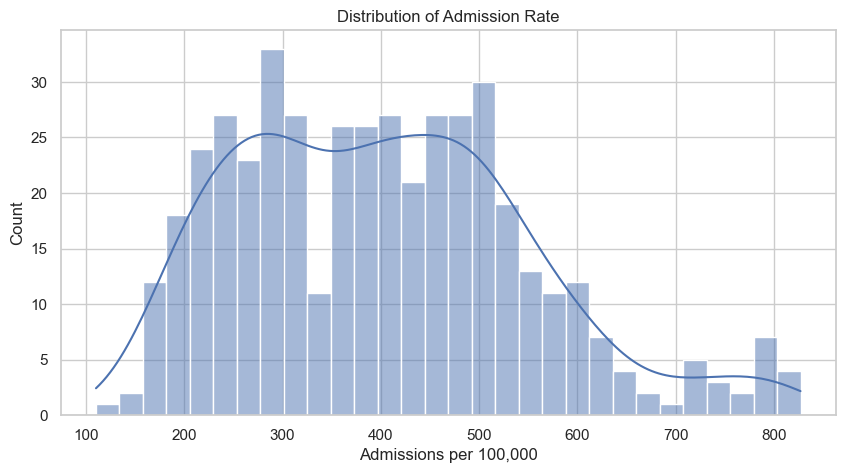

In [9]:
# admission rate distribution

plt.figure(figsize=(10,5))

sns.histplot(

    df["admission_rate_per_100k"],

    bins=30,

    kde=True

)

plt.title("Distribution of Admission Rate")

plt.xlabel("Admissions per 100,000")

plt.show()

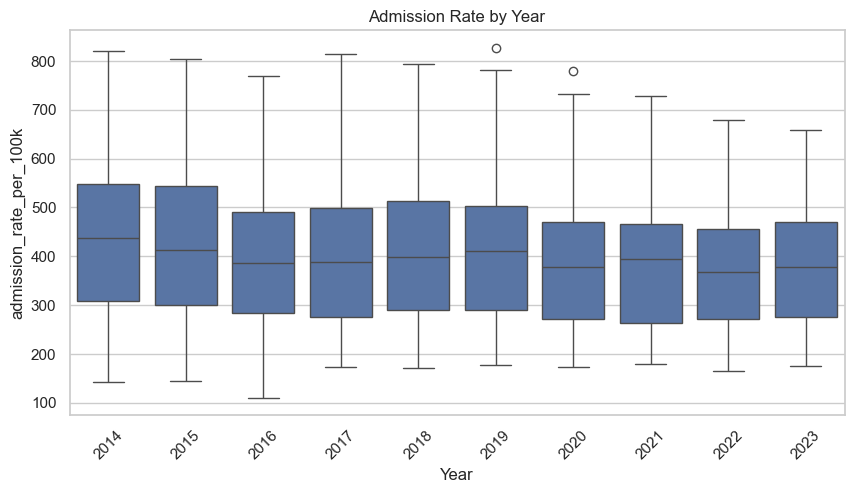

In [10]:
# admission rate by year

plt.figure(figsize=(10,5))

sns.boxplot(

    data=df,

    x="Year",

    y="admission_rate_per_100k"

)

plt.xticks(rotation=45)

plt.title("Admission Rate by Year")

plt.show()

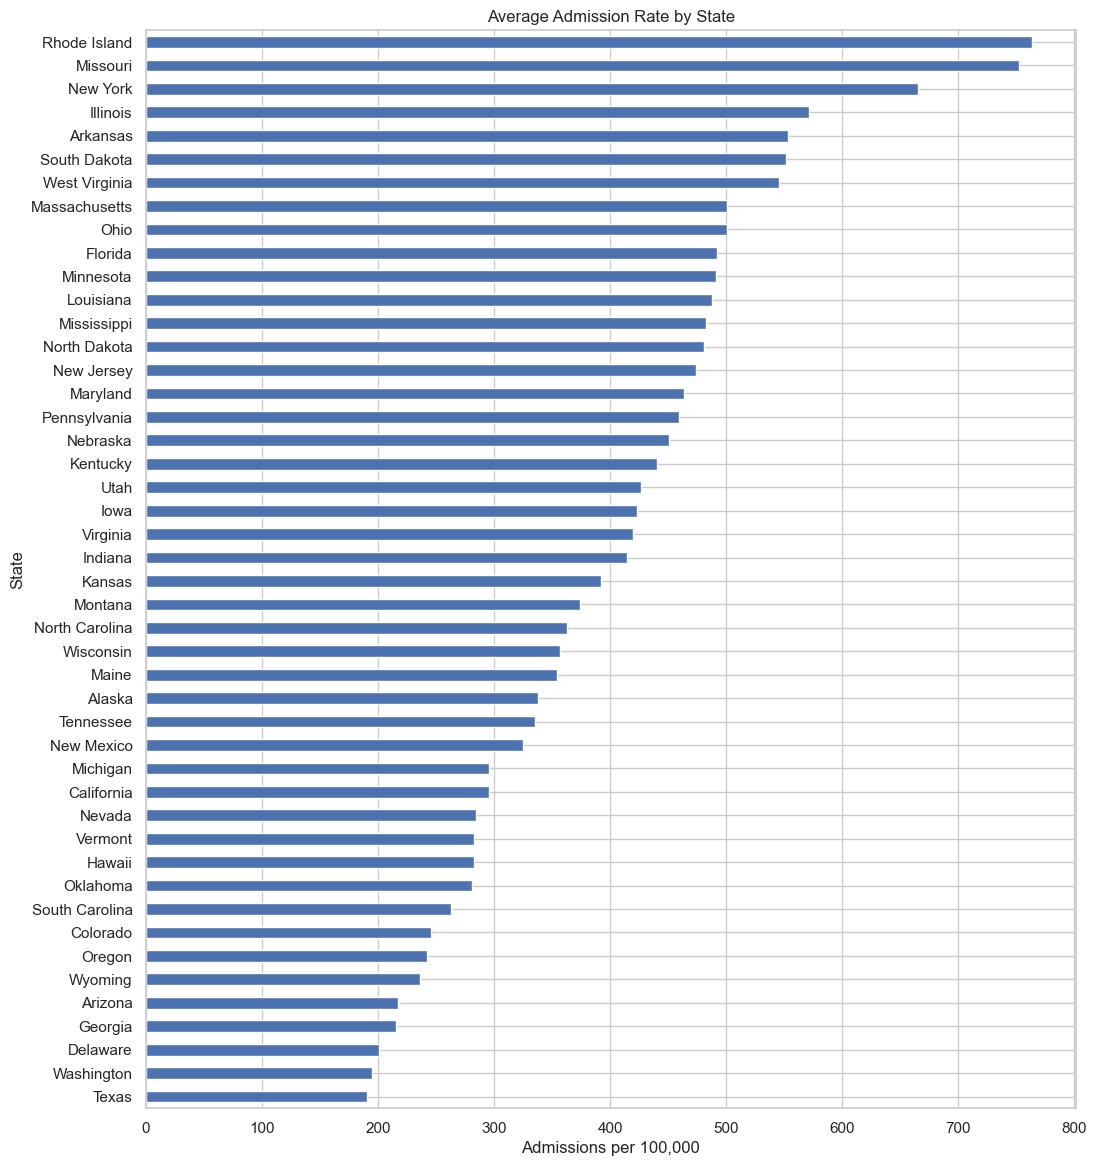

In [11]:
# AVE admission rate by state

state_mean = (

    df

    .groupby("State")["admission_rate_per_100k"]

    .mean()

    .sort_values()

)

plt.figure(figsize=(12,14))

state_mean.plot.barh()

plt.title("Average Admission Rate by State")

plt.xlabel("Admissions per 100,000")

plt.show()

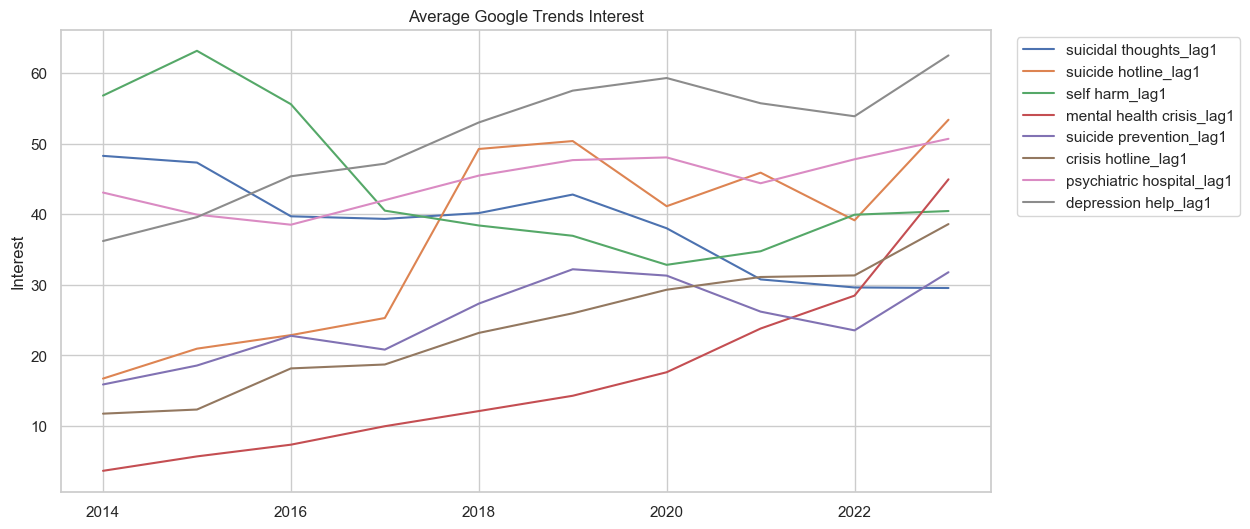

In [12]:
# Google Trends over time

trend_cols = [

    c for c in df.columns

    if "_lag1" in c

]

trend_year = (

    df

    .groupby("Year")[trend_cols]

    .mean()

)

plt.figure(figsize=(12,6))

for col in trend_cols:

    plt.plot(

        trend_year.index,

        trend_year[col],

        label=col

    )

plt.legend(

    bbox_to_anchor=(1.02,1),

    loc="upper left"

)

plt.title("Average Google Trends Interest")

plt.ylabel("Interest")

plt.show()

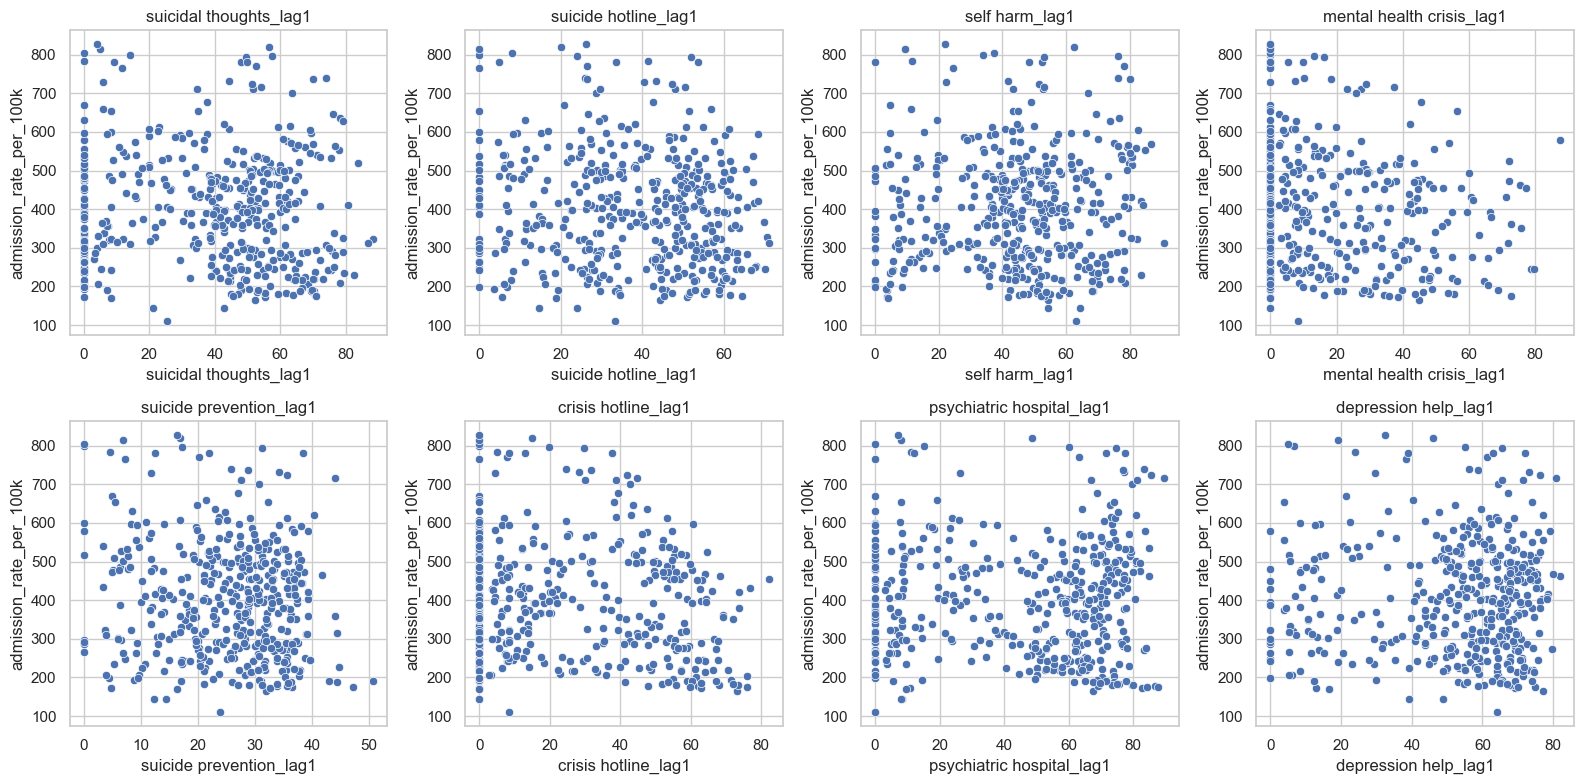

In [13]:
# scatterplots vs. target

fig, axes = plt.subplots(2,4, figsize=(16,8))

axes = axes.flatten()

for ax, col in zip(axes, trend_cols):

    sns.scatterplot(

        data=df,

        x=col,

        y="admission_rate_per_100k",

        ax=ax

    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

In [14]:
# correlation matrix

corr = (

    df[

        trend_cols +

        ["admission_rate_per_100k"]

    ]

    .corr()

)

display(corr)



,suicidal thoughts_lag1,suicide hotline_lag1,self harm_lag1,mental health crisis_lag1,suicide prevention_lag1,crisis hotline_lag1,psychiatric hospital_lag1,depression help_lag1,admission_rate_per_100k
suicidal thoughts_lag1,1.000000,0.430640,0.826770,0.342861,0.581585,0.532801,0.829927,0.694692,-0.056890
suicide hotline_lag1,0.430640,1.000000,0.249718,0.549499,0.820099,0.521921,0.582144,0.806856,-0.108194
self harm_lag1,0.826770,0.249718,1.000000,0.290466,0.407552,0.393111,0.693264,0.572019,0.048104
mental health crisis_lag1,0.342861,0.549499,0.290466,1.000000,0.562259,0.805589,0.629439,0.586186,-0.157086
suicide prevention_lag1,0.581585,0.820099,0.407552,0.562259,1.000000,0.583559,0.700048,0.830038,-0.114690
crisis hotline_lag1,0.532801,0.521921,0.393111,0.805589,0.583559,1.000000,0.730565,0.606580,-0.155670
psychiatric hospital_lag1,0.829927,0.582144,0.693264,0.629439,0.700048,0.730565,1.000000,0.797977,-0.006331
depression help_lag1,0.694692,0.806856,0.572019,0.586186,0.830038,0.606580,0.797977,1.000000,0.012105
admission_rate_per_100k,-0.056890,-0.108194,0.048104,-0.157086,-0.114690,-0.155670,-0.006331,0.012105,1.000000


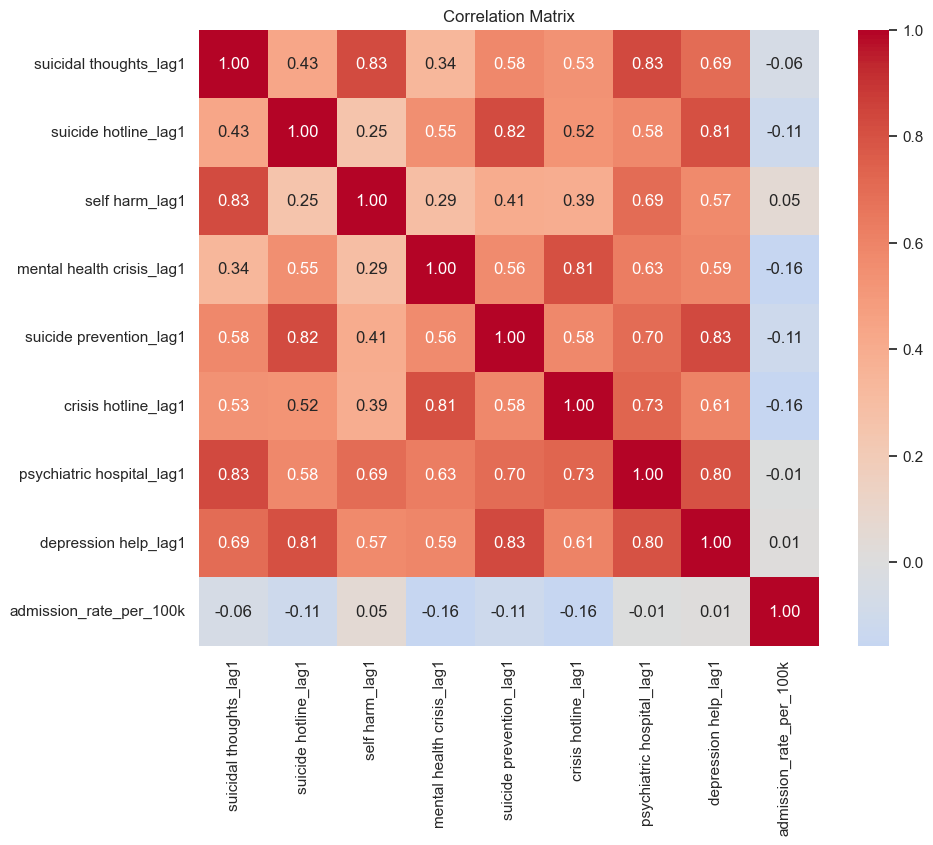

In [15]:
# correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(

    corr,

    cmap="coolwarm",

    center=0,

    annot=True,

    fmt=".2f"

)

plt.title("Correlation Matrix")

plt.show()

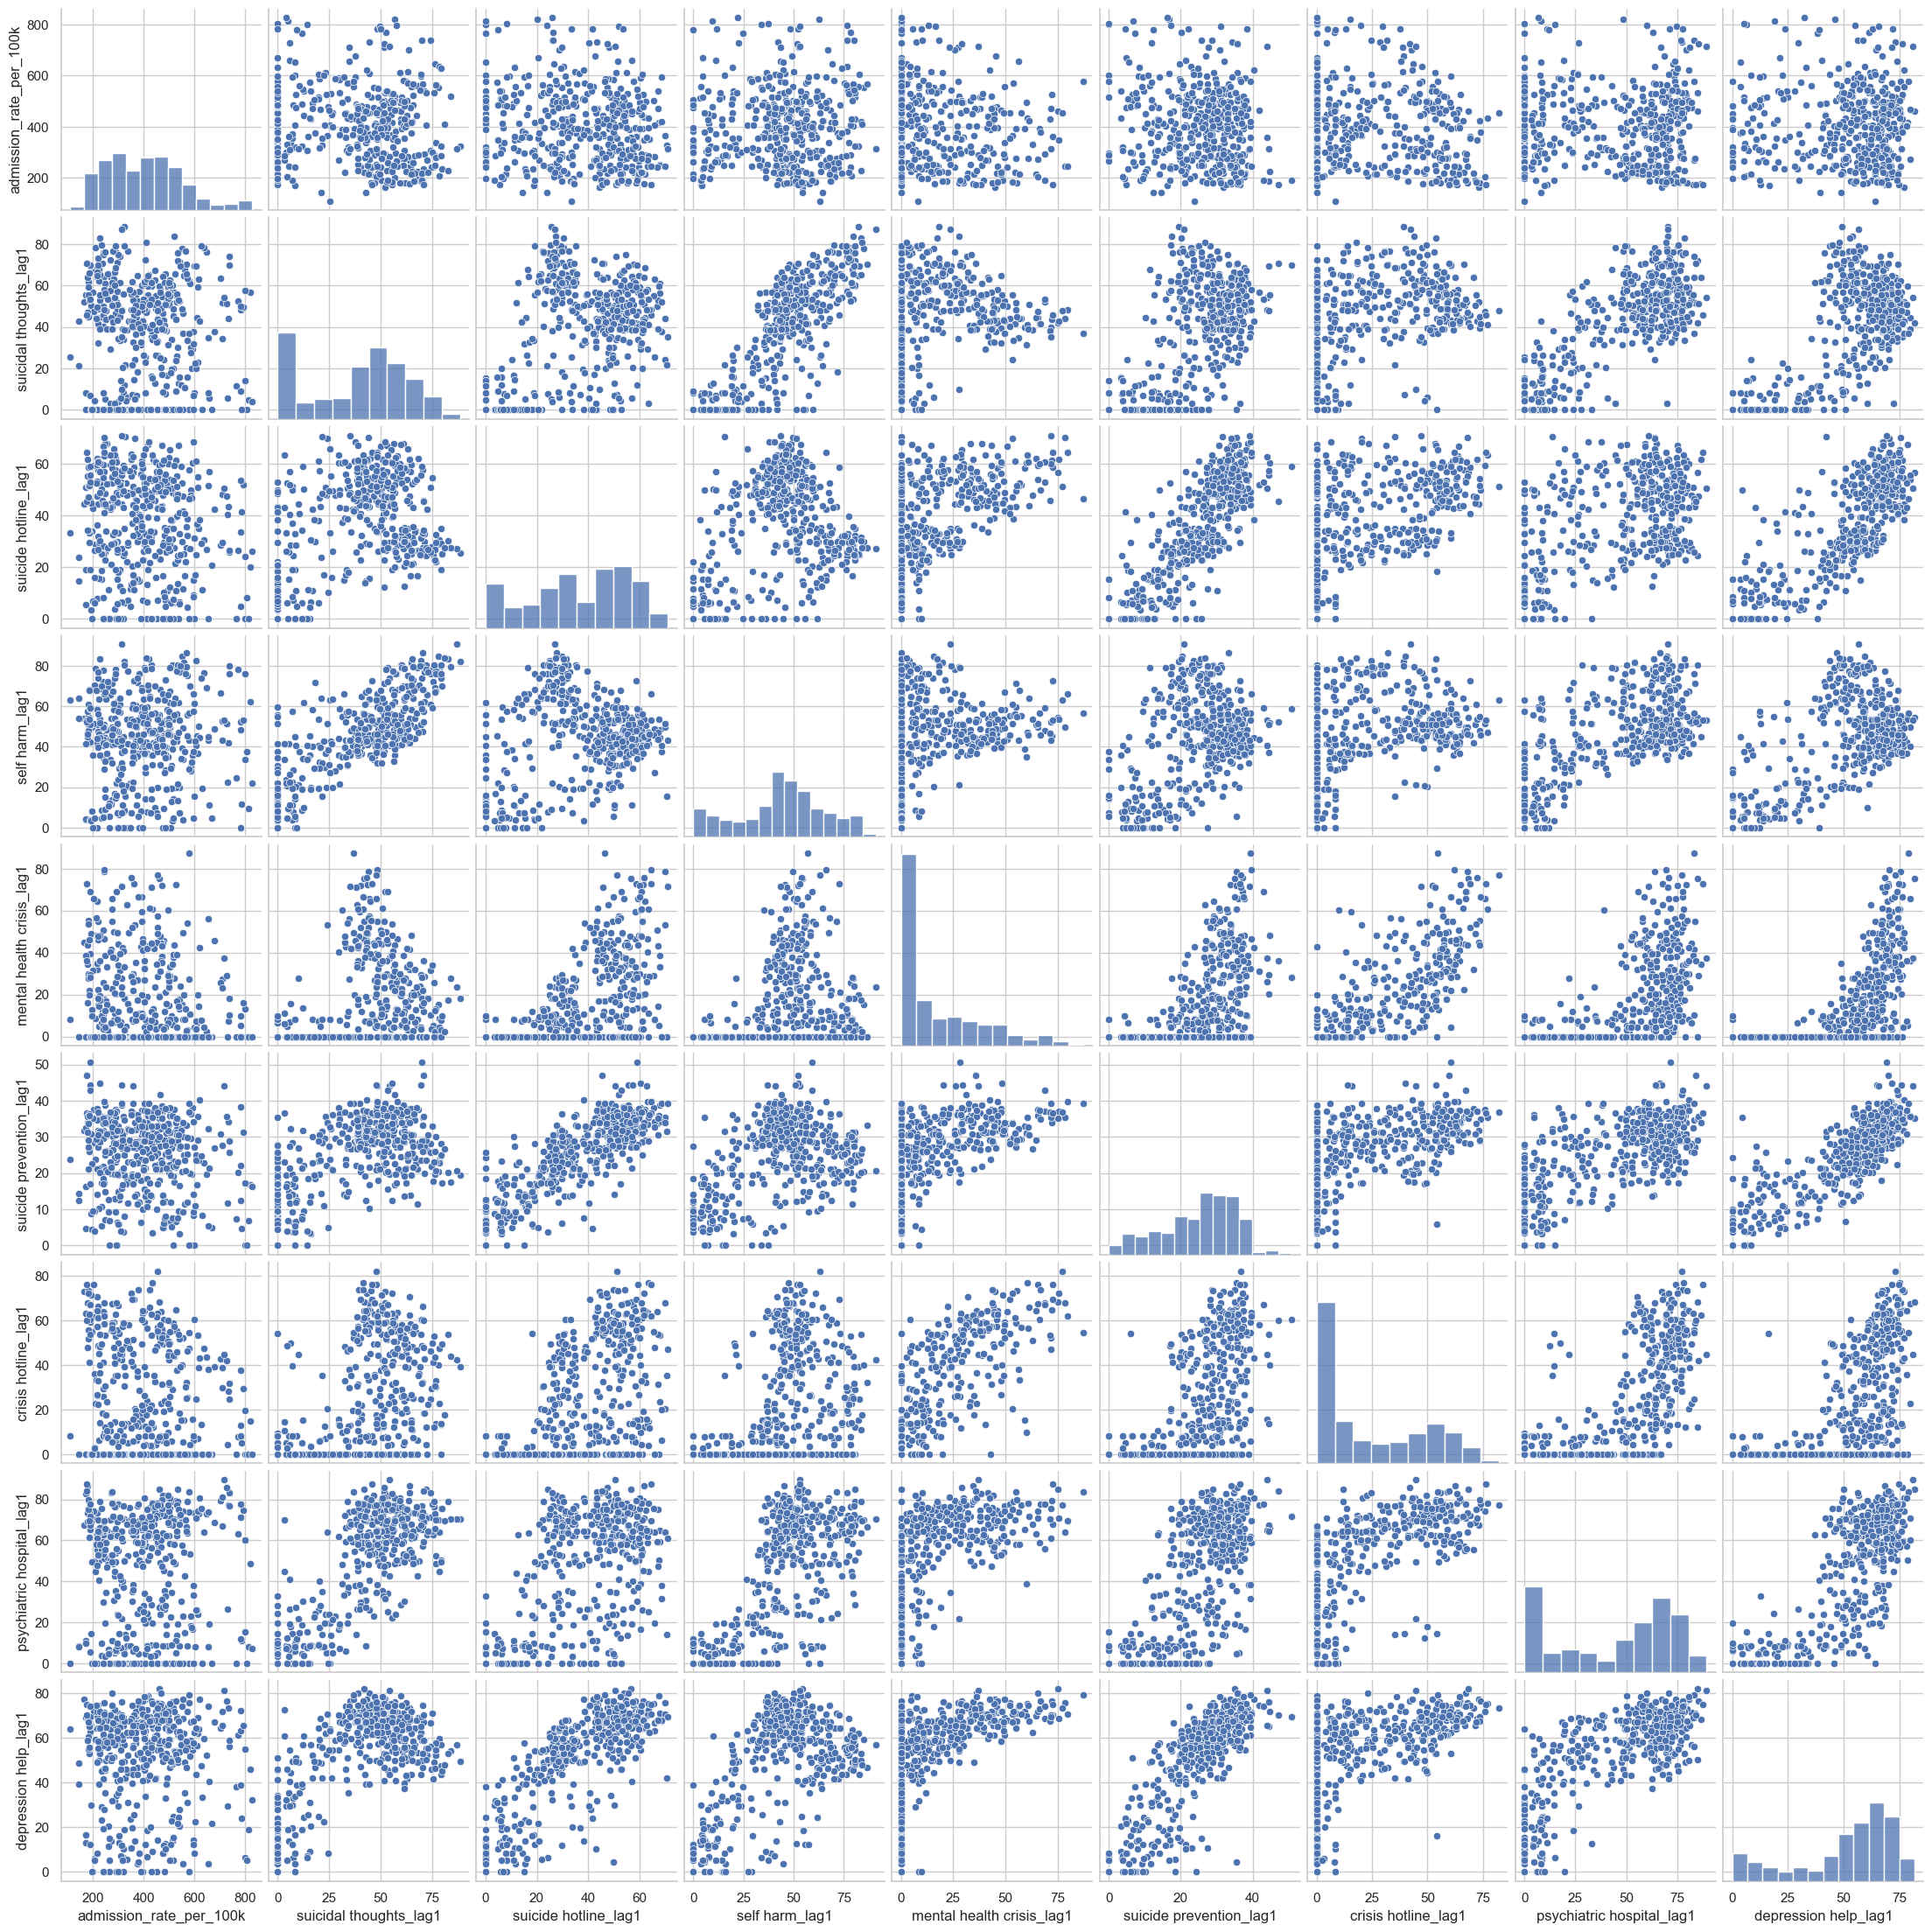

In [26]:
# pairwise relationships

sns.pairplot(
    df[
        [
            "admission_rate_per_100k",
            "suicidal thoughts_lag1",
            "suicide hotline_lag1",
            "self harm_lag1",
            "mental health crisis_lag1",
            "suicide prevention_lag1",
            "crisis hotline_lag1",
            "psychiatric hospital_lag1",
            "depression help_lag1"
        ]
    ]
)

plt.show()

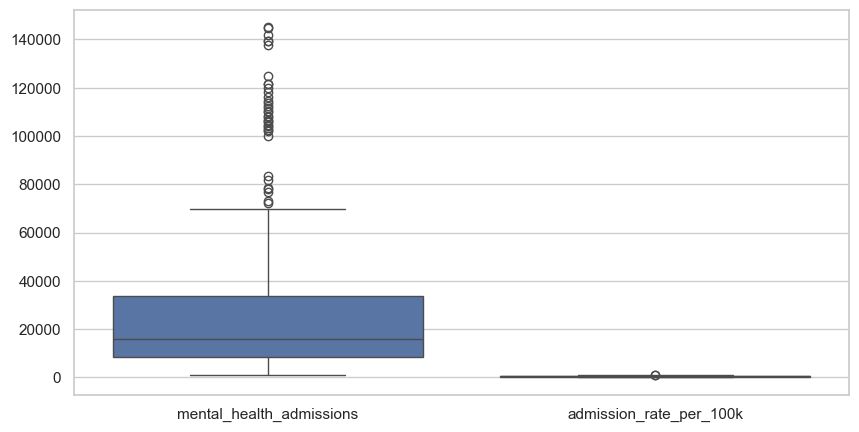

In [18]:
# outlier inspections

plt.figure(figsize=(10,5))

sns.boxplot(

    data=df[

        [

            "mental_health_admissions",

            "admission_rate_per_100k"

        ]

    ]

)

plt.show()

In [19]:
# predictor variability 

variability = (

    df[trend_cols]

    .std()

    .sort_values(

        ascending=False

    )

)

display(variability)

psychiatric hospital_lag1    28.624648
crisis hotline_lag1          24.543965
suicidal thoughts_lag1       24.528710
depression help_lag1         22.206077
self harm_lag1               21.530546
mental health crisis_lag1    20.777556
suicide hotline_lag1         19.307883
suicide prevention_lag1      10.301126
dtype: float64

In [20]:
# EDA summary

print("="*60)
print("EDA COMPLETE")
print("="*60)

print(f"Observations: {len(df):,}")
print(f"States: {df['State'].nunique()}")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")

print("\nVariables")

print(df.columns.tolist())

EDA COMPLETE
Observations: 452
States: 46
Years: 2014 - 2023

Variables
['State', 'Year', 'state_population', 'mental_health_admissions', 'admission_rate_per_100k', 'suicidal thoughts_lag1', 'suicide hotline_lag1', 'self harm_lag1', 'mental health crisis_lag1', 'suicide prevention_lag1', 'crisis hotline_lag1', 'psychiatric hospital_lag1', 'depression help_lag1']


In [27]:
# EDA tables & visualizations export


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


# directories

FIG_DIR = Path(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/"
    "DS Portfolio github friendly/"
    "Team-Rho-Capstone-Project.cb/figures"
)

TABLE_DIR = FIG_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Helper Function: save table PNG


def save_table_png(
    dataframe,
    filename,
    title,
    figsize=(12,8),
    fontsize=8
):

    fig, ax = plt.subplots(figsize=figsize)

    ax.axis("off")

    table = ax.table(
        cellText=dataframe.values,
        colLabels=dataframe.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1,1.5)

    for (r,c), cell in table.get_celld().items():

        if r == 0:
            cell.set_facecolor("#2C3E50")
            cell.set_text_props(
                color="white",
                weight="bold"
            )

    fig.text(
        .5,
        .95,
        title,
        ha="center",
        fontsize=14,
        weight="bold"
    )

    plt.subplots_adjust(top=.85)

    plt.savefig(
        TABLE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()



# table exports
# Table 1: descriptive stats


numeric = df.select_dtypes(include=np.number)

desc = numeric.describe().T

desc["median"] = numeric.median()
desc["skew"] = numeric.skew()
desc["kurtosis"] = numeric.kurtosis()


desc.to_csv(
    TABLE_DIR /
    "continuous_descriptive_statistics.csv"
)


table1 = (
    desc.reset_index()
    .rename(columns={
        "index":"Variable",
        "std":"Std Dev",
        "min":"Minimum",
        "max":"Maximum",
        "50%":"Median"
    })
    .round(2)
)


save_table_png(
    table1,
    "Table_1_Descriptive_Statistics_Modeling_Variables.png",
    "Table 1. Descriptive Statistics for Modeling Variables",
    figsize=(18,8)
)

# Table 2: State-Level summary

state_summary = (

    df.groupby("State")
    .agg(
        Avg_Admission_Rate=
        ("admission_rate_per_100k","mean"),

        Avg_Admissions=
        ("mental_health_admissions","mean"),

        Avg_Population=
        ("state_population","mean")
    )
    .sort_values(
        "Avg_Admission_Rate",
        ascending=False
    )
)


state_summary.to_csv(
    TABLE_DIR /
    "state_admission_summary.csv"
)


save_table_png(
    state_summary.reset_index().round(0),
    "Table_2_state_level_admission_variation.png",
    "Table 2. Average Psychiatric Admission Rates, Admissions, and Population by State",
    figsize=(10,15),
    fontsize=9
)

# Table 3: state frequency

state_frequency = (

    df["State"]
    .value_counts()
    .reset_index()

)

state_frequency.columns = [
    "State",
    "Frequency"
]


state_frequency["Percent"] = (
    state_frequency["Frequency"] /
    len(df) * 100
).round(2)


state_frequency.to_csv(
    TABLE_DIR /
    "state_frequency_summary.csv",
    index=False
)


save_table_png(
    state_frequency,
    "Table_3_state_frequency.png",
    "Table 3. State Observation Frequency",
    figsize=(8,12)
)

# correlation table

trend_cols = [
    c for c in df.columns
    if "_lag1" in c
]


corr = (
    df[
        trend_cols +
        ["admission_rate_per_100k"]
    ]
    .corr()
)


corr.to_csv(
    TABLE_DIR /
    "google_trends_target_correlation.csv"
)

# FIGURES

# Figure 1: admission rate distribution


plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="admission_rate_per_100k",
    kde=True
)

plt.title(
    "Figure 1. Distribution of Psychiatric Admission Rate"
)

plt.xlabel(
    "Admissions per 100,000 Residents"
)

plt.savefig(
    FIG_DIR /
    "01_admission_rate_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Figure 2: admission rate by year

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Year",
    y="admission_rate_per_100k"
)

plt.xticks(rotation=45)

plt.title(
    "Figure 2. Psychiatric Admission Rate Variation by Year"
)

plt.xlabel("Year")
plt.ylabel("Admissions per 100,000 Residents")


plt.savefig(
    FIG_DIR /
    "02_admission_rate_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Figure 3: admission rate by state

plt.figure(figsize=(12,14))


(
    df.groupby("State")
    ["admission_rate_per_100k"]
    .mean()
    .sort_values()
    .plot
    .barh()
)


plt.title(
    "Figure 3. Average Psychiatric Admission Rate by State"
)

plt.xlabel(
    "Admissions per 100,000 Residents"
)


plt.savefig(
    FIG_DIR /
    "03_admission_rate_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Figure 4: Google Trends over time

trend_year = (
    df.groupby("Year")[trend_cols]
    .mean()
)


trend_year.plot(
    figsize=(12,6)
)


plt.title(
    "Figure 4. Average Google Trends Search Interest Over Time"
)

plt.ylabel(
    "Google Trends Interest"
)


plt.savefig(
    FIG_DIR /
    "04_google_trends_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Figure 5: Google Trends predictors vs outcome

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16,8)
)

axes = axes.flatten()


for ax, col in zip(axes, trend_cols):

    sns.scatterplot(
        data=df,
        x=col,
        y="admission_rate_per_100k",
        ax=ax
    )

    ax.set_title(
        col.replace("_lag1","")
    )

    ax.set_xlabel("Search Interest")
    ax.set_ylabel("Admission Rate")


plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "05_google_trends_vs_admission_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Figure 6:correlation heatmap

plt.figure(figsize=(10,8))


sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)


plt.title(
    "Figure 6. Correlation Matrix: Google Trends Predictors and Admission Rate"
)


plt.savefig(
    FIG_DIR /
    "06_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Figure 7: pairwise relationships

pair_cols = [
    "admission_rate_per_100k",
    "suicidal thoughts_lag1",
    "suicide hotline_lag1",
    "self harm_lag1",
    "mental health crisis_lag1",
    "suicide prevention_lag1",
    "crisis hotline_lag1",
    "psychiatric hospital_lag1",
    "depression help_lag1"
]

sns.pairplot(
    df[pair_cols]
)

plt.savefig(
    FIG_DIR /
    "07_pairwise_relationships.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Figure 8: predictor variability

variability = (
    df[trend_cols]
    .std()
    .sort_values()
)


plt.figure(figsize=(10,6))


variability.plot.barh()


plt.title(
    "Figure 8. Variability of Google Trends Predictors"
)

plt.xlabel(
    "Standard Deviation"
)


plt.savefig(
    FIG_DIR /
    "08_predictor_variability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Figure 9: admission outlier inspect

plt.figure(figsize=(8,5))


sns.boxplot(
    data=df[
        [
            "mental_health_admissions",
            "admission_rate_per_100k"
        ]
    ]
)


plt.title(
    "Figure 9. Admission Variable Outlier Inspection"
)


plt.savefig(
    FIG_DIR /
    "09_admission_outlier_inspection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# EDA summary export


eda_summary = pd.DataFrame({

    "Metric":[
        "Observations",
        "States",
        "Year Range",
        "Variables"
    ],

    "Value":[
        len(df),
        df["State"].nunique(),
        f"{df['Year'].min()}-{df['Year'].max()}",
        ", ".join(df.columns)
    ]

})


eda_summary.to_csv(
    TABLE_DIR /
    "EDA_summary.csv",
    index=False
)


print("EDA EXPORT COMPLETE")

EDA EXPORT COMPLETE


In [23]:

# Hypothesis & Prediction Evidence Summary Table


from pathlib import Path
import pandas as pd
import numpy as np

# output directory


FIG_DIR = Path(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/"
    "DS Portfolio github friendly/"
    "Team-Rho-Capstone-Project.cb/figures"
)

TABLE_DIR = FIG_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# identify Google Trends predictors


trend_cols = [
    c for c in df.columns
    if "_lag1" in c
]


# calculate Hypothesis-Relevant stats


hypothesis_summary = []

for col in trend_cols:

    correlation = (
        df[[col, "admission_rate_per_100k"]]
        .corr()
        .iloc[0,1]
    )

    hypothesis_summary.append({

        "Predictor": col.replace("_lag1",""),

        "Mean Search Interest":
            round(df[col].mean(),2),

        "Std Dev Search Interest":
            round(df[col].std(),2),

        "Correlation with Future Admission Rate":
            round(correlation,3),

        "Direction of Association":
            "Positive" if correlation > 0
            else "Negative"

    })


hypothesis_table = pd.DataFrame(
    hypothesis_summary
)


# overall dataset context


dataset_summary = pd.DataFrame({

    "Metric": [
        "Observations",
        "States",
        "Years",
        "Outcome Variable",
        "Outcome Mean",
        "Outcome Standard Deviation"
    ],

    "Value": [
        len(df),
        df["State"].nunique(),
        f"{df['Year'].min()}-{df['Year'].max()}",
        "Psychiatric admissions per 100,000",
        round(df["admission_rate_per_100k"].mean(),2),
        round(df["admission_rate_per_100k"].std(),2)
    ]

})

#display tables in notebook

print("Hypothesis & Prediction Evidence Summary")
display(hypothesis_table)

print("Dataset Outcome Summary")
display(dataset_summary)


# save CSV tables


hypothesis_table.to_csv(
    TABLE_DIR /
    "hypothesis_prediction_google_trends_summary.csv",
    index=False
)

dataset_summary.to_csv(
    TABLE_DIR /
    "hypothesis_prediction_dataset_summary.csv",
    index=False
)

# create Report-Ready combined table

report_table = hypothesis_table.copy()

report_table.insert(
    0,
    "Outcome Evaluated",
    "Future Psychiatric Admission Rate"
)

report_table.to_csv(
    TABLE_DIR /
    "Table_Hypothesis_Prediction_Evidence.csv",
    index=False
)


print(
    "\nSaved report table:"
)

print(
    TABLE_DIR /
    "Table_Hypothesis_Prediction_Evidence.csv"
)

Hypothesis & Prediction Evidence Summary


,Predictor,Mean Search Interest,Std Dev Search Interest,Correlation with Future Admission Rate,Direction of Association
0,suicidal thoughts,38.57,24.53,-0.057,Negative
1,suicide hotline,36.55,19.31,-0.108,Negative
2,self harm,43.82,21.53,0.048,Positive
3,mental health crisis,16.69,20.78,-0.157,Negative
4,suicide prevention,25.07,10.30,-0.115,Negative
5,crisis hotline,24.04,24.54,-0.156,Negative
6,psychiatric hospital,44.76,28.62,-0.006,Negative
7,depression help,51.06,22.21,0.012,Positive


Dataset Outcome Summary


,Metric,Value
0,Observations,452
1,States,46
2,Years,2014-2023
3,Outcome Variable,"Psychiatric admissions per 100,000"
4,Outcome Mean,401.8
5,Outcome Standard Deviation,148.15



Saved report table:
/Users/caseybrookshier/Desktop/Data Science job attainment planning/DS Portfolio github friendly/Team-Rho-Capstone-Project.cb/figures/tables/Table_Hypothesis_Prediction_Evidence.csv
